In [ ]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler




import torch
from torch import nn    # 대부분의 신경망 구조가 들어있음.
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


In [2]:
# device 준비: cpu, gpu(cuda)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')


Using cuda device


In [ ]:
# 필요 함수 생성
# 0. 데이터 준비 함수
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)             # val tensor로 변환
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)


    # return train_loader: 학습데이터를 적재하는 것 => 모델에 데이터 넣어 줌. x_val_tensor, y_val_tensor
    return train_loader, x_val_tensor, y_val_tensor

In [ ]:
# 1. 학습 함수     데이터 -> 모델 -> 손실함수(오차 구하는 함수) -> 최적화(w)
# 데이터 로더 -> 모델 -> 예측값 -> 오차 구함(손실함수) -> 옵티마이저(학습), 오차가 최소가 되는 w 찾기.
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기          data|label 하나를 데이터셋이라고 함. 
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0                                     # 학습 시 오차 저장하는 변수
    model.train()                                   # 훈련 모드로 설정, '학습해라'가 아님.
    for x, y in dataloader:     # batch : 현재 배치 번호, (x, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)           # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 연결


        # Feed Forward
        pred = model(x)                             # x라는 데이터로 순전파 학습. 입력층 (32 X 12) batch size: 32, columns: 12  ->  출력층(32 X 1)(2차원으로나옴). 예측값 나옴.
        loss = loss_fn(pred, y)                     # y : 원래 답(32,1)(2차원으로 나옴) .view(-1, 1)로 값 맞춤.  -> 오차가 나온다.
        tr_loss += loss


        # Loss Backpropagation(오차 역전파), 전파 => 전달    출력층 쪽 오차가 앞쪽으로 전달.(예전에는 오차가 앞으로 가지 못 했음 -> 성능 낮..)
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산만 함.
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트(Wt = Wt-1  - a*(기울기)). step에서 Wt와 Wt-1 별 차이 없을 때까지 업데이트 반복
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지


    tr_loss /= num_batches          # 모든 배치에서의 loss 평균


    return tr_loss.item()


In [ ]:
# 2. 평가 함수 : 테스트 데이터로 검증한다. x_val_tensor, y_val_tensor
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정
                                        # 평가모드니까 순전파만 할 예정. 예측값만 뽑으면 됨.

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)                 # 예측값 나옴.
        eval_loss = loss_fn(pred, y).item()    # 학습에 사용했던 손실함수로 예측 값 pred와 실제 값 y 사이의 손실 계산


    return eval_loss, pred

In [8]:
# 3. 시각화 : 학습 그래프 그림.
# 3. 시각화 함수 : 학습 그래프 그린다
def dl_learning_curve(tr_loss_list, val_loss_list): # tr_loss : 학습 오차, val_loss : 검증 오차
    epochs = list(range(1, len(tr_loss_list)+1)) # 에폭수 : 100
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # plot 점으로 선그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')  # plot 점으로 선그래프


    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()


In [9]:
# 데이터 전처리
# 데이터 로딩 및 준비
# 데이터 로딩
path = 'https://bit.ly/ds_boston_csv'
data = pd.read_csv(path)


# x, y 분할
target = 'medv'
x = data.drop(target, axis = 1) # 이번에는 12개의 입력변수 모두를 이용합니다.
y = data.loc[:, target]


# train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


In [10]:
# 데이터 로더
# y_train, y_val을 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values


# 데이터 로더 준비
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)


In [11]:
# 모델링: 모델 구조 설계
n_feature = x.shape[1]                          # 컬럼 개수
model2 = nn.Sequential(nn.Linear(n_feature, 2), # 입력 -> 12, 출력 -> 2 <= 입력층
                       nn.ReLU(),              
                       nn.Linear(2, 1)          # 2,1
                       ).to(device)


In [14]:
# 손실 함수, 옵티마이저 준비
loss_fn = nn.MSELoss()
optimizer = Adam(model2.parameters(), lr=0.01)


# 학습
epochs = 1000 # 100번 반복 학습
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model2, loss_fn, device)
    tr_loss_list.append(tr_loss) # learning curve 그리기 위해 리스트에 추가
    val_loss_list.append(val_loss) # learning curve 그리기 위해 리스트에 추가
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 230.927200, val loss : 178.472046
Epoch 2, train loss : 227.406876, val loss : 175.740082
Epoch 3, train loss : 228.284409, val loss : 173.057953
Epoch 4, train loss : 222.658096, val loss : 170.416367
Epoch 5, train loss : 218.322815, val loss : 167.833649
Epoch 6, train loss : 214.936874, val loss : 165.296783
Epoch 7, train loss : 211.089508, val loss : 162.809525
Epoch 8, train loss : 208.846085, val loss : 160.388199
Epoch 9, train loss : 207.010788, val loss : 157.972275
Epoch 10, train loss : 202.379547, val loss : 155.627930
Epoch 11, train loss : 199.642395, val loss : 153.314301
Epoch 12, train loss : 198.618118, val loss : 151.048721
Epoch 13, train loss : 198.578598, val loss : 148.816376
Epoch 14, train loss : 192.528183, val loss : 146.629547
Epoch 15, train loss : 189.794830, val loss : 144.512100
Epoch 16, train loss : 191.460190, val loss : 142.384705
Epoch 17, train loss : 189.130081, val loss : 140.319519
Epoch 18, train loss : 186.247452, val l

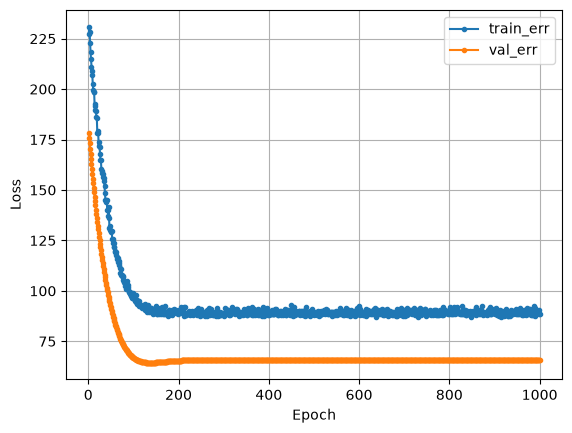

In [15]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)

In [ ]:
# 예측 결과
_, pred = evaluate(x_val_ts, y_val_ts, model2, loss_fn, device)


# 모델 평가
mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
print(f'MAE : {mae}')
print(f'MAPE : {mape}')
 

MAE : 5.663463115692139
MAPE : 0.33443108201026917
